<a href="https://colab.research.google.com/github/ChanchalDonekar/laptop-price-prediction/blob/main/LapTopPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import io

df = pd.read_csv('/content/laptop_prices.csv')

df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [ ]:
df.shape

(1275, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

In [ ]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight',
       'Price_euros', 'Screen', 'ScreenW', 'ScreenH', 'Touchscreen',
       'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model',
       'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType',
       'SecondaryStorageType', 'GPU_company', 'GPU_model'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Company,0
Product,0
TypeName,0
Inches,0
Ram,0
OS,0
Weight,0
Price_euros,0
Screen,0
ScreenW,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,8.440784,2.040525,1134.969059,1900.043922,1073.904314,2.302980,444.517647,176.069020
std,1.429470,5.097809,0.669196,700.752504,493.346186,283.883940,0.503846,365.537726,415.960655
min,10.100000,2.000000,0.690000,174.000000,1366.000000,768.000000,0.900000,8.000000,0.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000,1080.000000,2.000000,256.000000,0.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,1496.500000,1920.000000,1080.000000,2.700000,512.000000,0.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000,2160.000000,3.600000,2048.000000,2048.000000


In [ ]:
print(df.columns.tolist())

['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight', 'Price_euros', 'Screen', 'ScreenW', 'ScreenH', 'Touchscreen', 'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model', 'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType', 'SecondaryStorageType', 'GPU_company', 'GPU_model']


In [ ]:
df.dtypes

,0
Company,object
Product,object
TypeName,object
Inches,float64
Ram,int64
OS,object
Weight,float64
Price_euros,float64
Screen,object
ScreenW,int64


In [ ]:
df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [ ]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].unique()[:20])


 Company
['Apple' 'HP' 'Acer' 'Asus' 'Dell' 'Lenovo' 'Chuwi' 'MSI' 'Microsoft'
 'Toshiba' 'Huawei' 'Xiaomi' 'Vero' 'Razer' 'Mediacom' 'Samsung' 'Google'
 'Fujitsu' 'LG']

 Product
['MacBook Pro' 'Macbook Air' '250 G6' 'Aspire 3' 'ZenBook UX430UN'
 'Swift 3' 'Inspiron 3567' 'MacBook 12"' 'IdeaPad 320-15IKB' 'XPS 13'
 'Vivobook E200HA' 'Legion Y520-15IKBN' '255 G6' 'Inspiron 5379'
 '15-BS101nv (i7-8550U/8GB/256GB/FHD/W10)' 'MacBook Air' 'Inspiron 5570'
 'Latitude 5590' 'ProBook 470' 'LapBook 15.6"']

 TypeName
['Ultrabook' 'Notebook' 'Netbook' 'Gaming' '2 in 1 Convertible'
 'Workstation']

 OS
['macOS' 'No OS' 'Windows 10' 'Mac OS X' 'Linux' 'Android' 'Windows 10 S'
 'Chrome OS' 'Windows 7']

 Screen
['Standard' 'Full HD' 'Quad HD+' '4K Ultra HD']

 Touchscreen
['No' 'Yes']

 IPSpanel
['Yes' 'No']

 RetinaDisplay
['Yes' 'No']

 CPU_company
['Intel' 'AMD' 'Samsung']

 CPU_model
['Core i5' 'Core i5 7200U' 'Core i7' 'A9-Series 9420' 'Core i7 8550U'
 'Core i5 8250U' 'Core i3 6006U' 'Core M 

In [ ]:
df.isnull().sum()

,0
Company,0
Product,0
TypeName,0
Inches,0
Ram,0
OS,0
Weight,0
Price_euros,0
Screen,0
ScreenW,0


In [ ]:
df = df.drop_duplicates()

print("Dataset shape:", df.shape)

Dataset shape: (1275, 23)


In [ ]:
print("Target column:", df['Price_euros'].name)
print("Target values:")
print(df['Price_euros'].head())

Target column: Price_euros
Target values:
0    1339.69
1     898.94
2     575.00
3    2537.45
4    1803.60
Name: Price_euros, dtype: float64


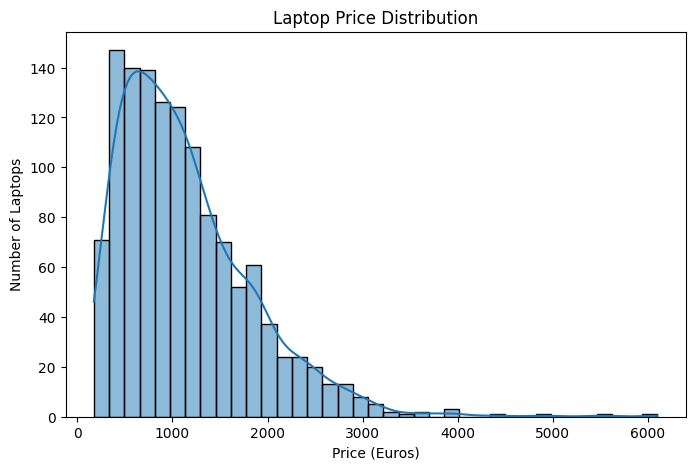

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Price_euros'], kde=True)

plt.title('Laptop Price Distribution')
plt.xlabel('Price (Euros)')
plt.ylabel('Number of Laptops')

plt.show()

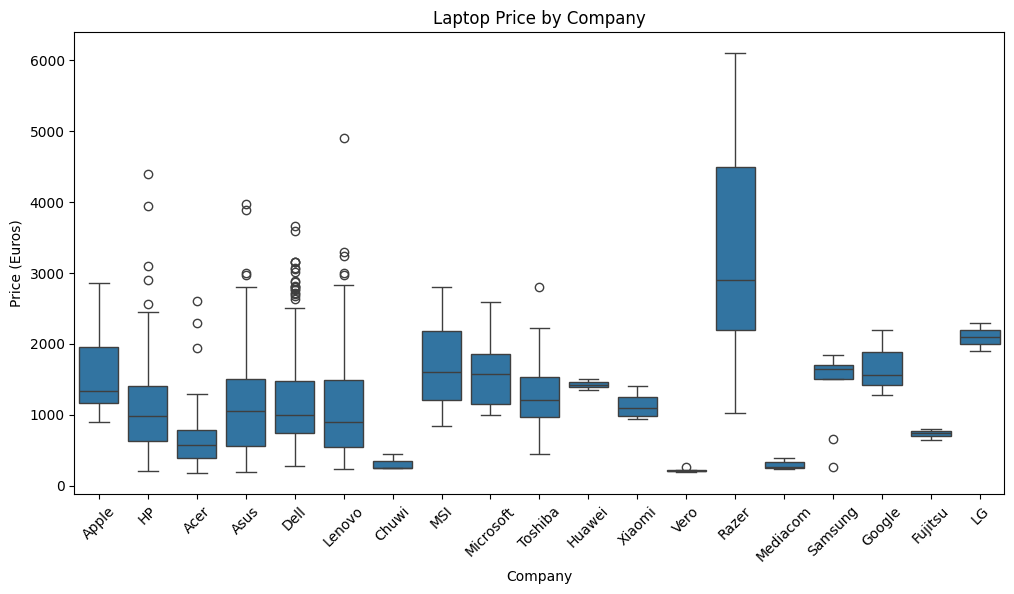

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(x='Company', y='Price_euros', data=df)

plt.title('Laptop Price by Company')
plt.xlabel('Company')
plt.ylabel('Price (Euros)')
plt.xticks(rotation=45)

plt.show()

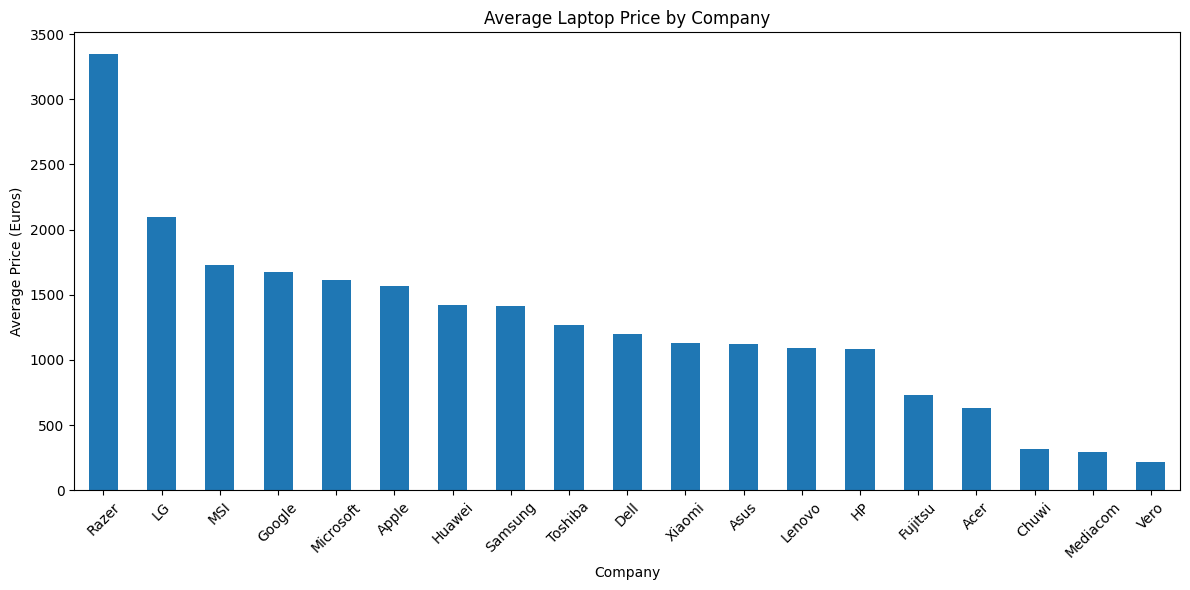

In [ ]:
company_price = df.groupby('Company')['Price_euros'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

company_price.plot(kind='bar')

plt.title('Average Laptop Price by Company')
plt.xlabel('Company')
plt.ylabel('Average Price (Euros)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

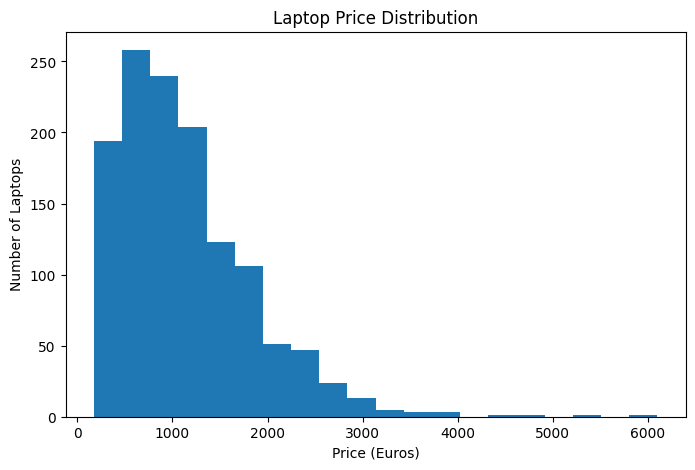

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Price_euros'], bins=20)

plt.title('Laptop Price Distribution')
plt.xlabel('Price (Euros)')
plt.ylabel('Number of Laptops')

plt.show()

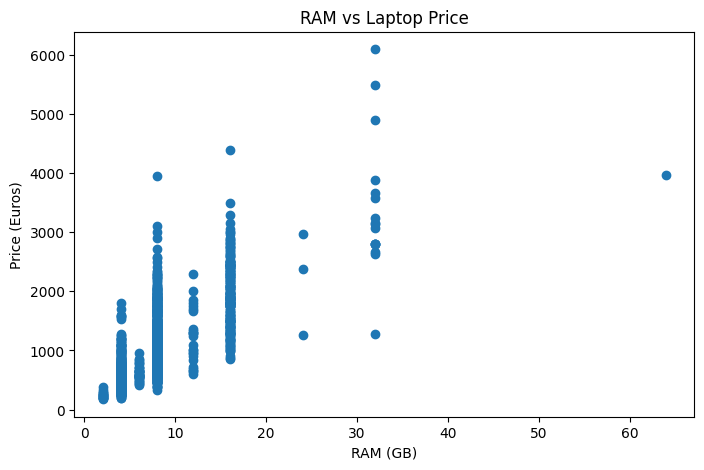

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Ram'], df['Price_euros'])

plt.title('RAM vs Laptop Price')
plt.xlabel('RAM (GB)')
plt.ylabel('Price (Euros)')

plt.show()

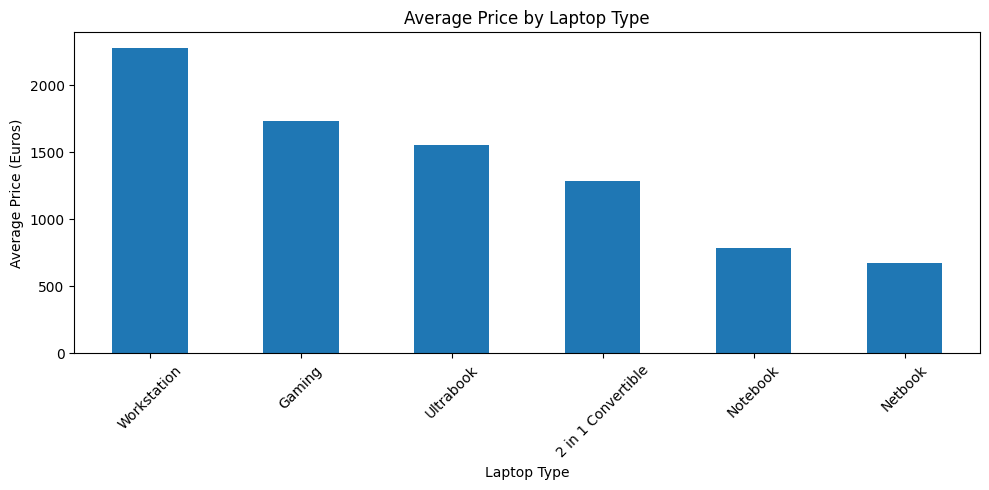

In [ ]:
type_price = df.groupby('TypeName')['Price_euros'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
type_price.plot(kind='bar')

plt.title('Average Price by Laptop Type')
plt.xlabel('Laptop Type')
plt.ylabel('Average Price (Euros)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
df.columns.tolist()

['Company',
 'Product',
 'TypeName',
 'Inches',
 'Ram',
 'OS',
 'Weight',
 'Price_euros',
 'Screen',
 'ScreenW',
 'ScreenH',
 'Touchscreen',
 'IPSpanel',
 'RetinaDisplay',
 'CPU_company',
 'CPU_freq',
 'CPU_model',
 'PrimaryStorage',
 'SecondaryStorage',
 'PrimaryStorageType',
 'SecondaryStorageType',
 'GPU_company',
 'GPU_model']

In [ ]:
features = [
    'Company',
    'TypeName',
    'Inches',
    'Ram',
    'Weight',
    'Screen',
    'ScreenW',
    'ScreenH',
    'Touchscreen',
    'CPU_company',
    'CPU_freq',
    'PrimaryStorage',
    'PrimaryStorageType',
    'GPU_company'
]

X = df[features]
y = df['Price_euros']

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Company', 'TypeName', 'Inches', 'Ram', 'Weight', 'Screen', 'ScreenW',
       'ScreenH', 'Touchscreen', 'CPU_company', 'CPU_freq', 'PrimaryStorage',
       'PrimaryStorageType', 'GPU_company'],
      dtype='object')

Target:
Price_euros


In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1275, 14)
y shape: (1275,)


In [ ]:
X.select_dtypes(include='object').columns

Index(['Company', 'TypeName', 'Screen', 'Touchscreen', 'CPU_company',
       'PrimaryStorageType', 'GPU_company'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1020, 14)
Testing data: (255, 14)


In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical Columns:")
print(categorical_cols.tolist())

print("\nNumerical Columns:")
print(numerical_cols.tolist())

Categorical Columns:
['Company', 'TypeName', 'Screen', 'Touchscreen', 'CPU_company', 'PrimaryStorageType', 'GPU_company']

Numerical Columns:
['Inches', 'Ram', 'Weight', 'ScreenW', 'ScreenH', 'CPU_freq', 'PrimaryStorage']


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Data Shape:", X_train_processed.shape)
print("Processed Testing Data Shape:", X_test_processed.shape)

Processed Training Data Shape: (1020, 49)
Processed Testing Data Shape: (255, 49)


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr_model = LinearRegression()

lr_model.fit(X_train_processed, y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr_model.predict(X_test_processed)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE : 260.6300940627527
RMSE: 346.1476341896686
R2 Score: 0.7585962047623799


In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt_model.fit(X_train_processed, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test_processed)

In [ ]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Results
MAE : 241.96605448143902
RMSE: 361.2332933363389
R2 Score: 0.7370961782644859


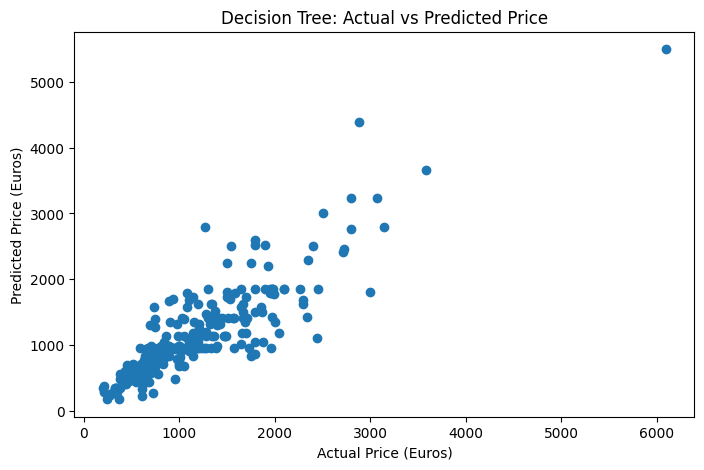

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_dt)

plt.xlabel('Actual Price (Euros)')
plt.ylabel('Predicted Price (Euros)')
plt.title('Decision Tree: Actual vs Predicted Price')

plt.show()

In [ ]:
y_pred_dt = dt_model.predict(X_test_processed)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Results
MAE : 241.96605448143902
RMSE: 361.2332933363389
R2 Score: 0.7370961782644859


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test_processed)

In [ ]:
y_pred_rf = rf_model.predict(X_test_processed)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE : 202.9360149071126
RMSE: 282.3043246997009
R2 Score: 0.8394329528305163


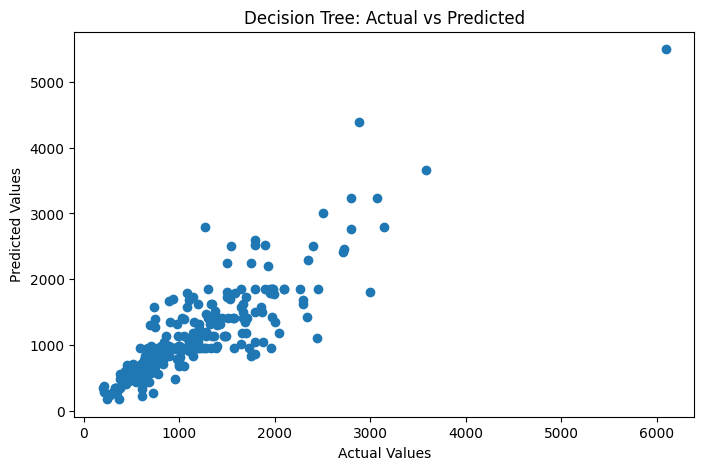

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_dt)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

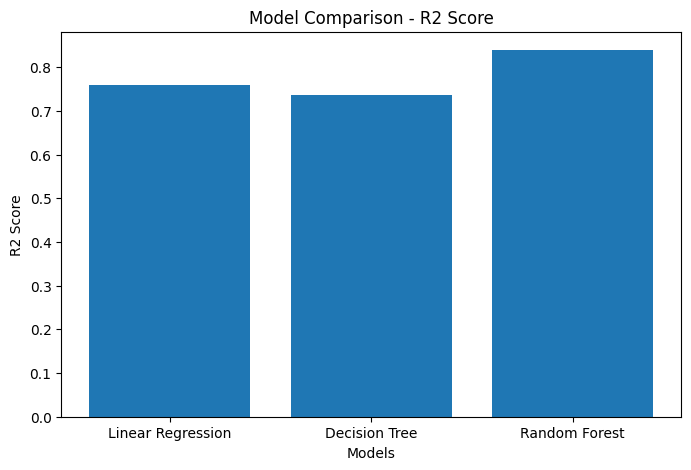

In [ ]:
models = ["Linear Regression", "Decision Tree", "Random Forest"]

r2_scores = [r2_lr, r2_dt, r2_rf]

plt.figure(figsize=(8, 5))

plt.bar(models, r2_scores)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison - R2 Score")

plt.show()

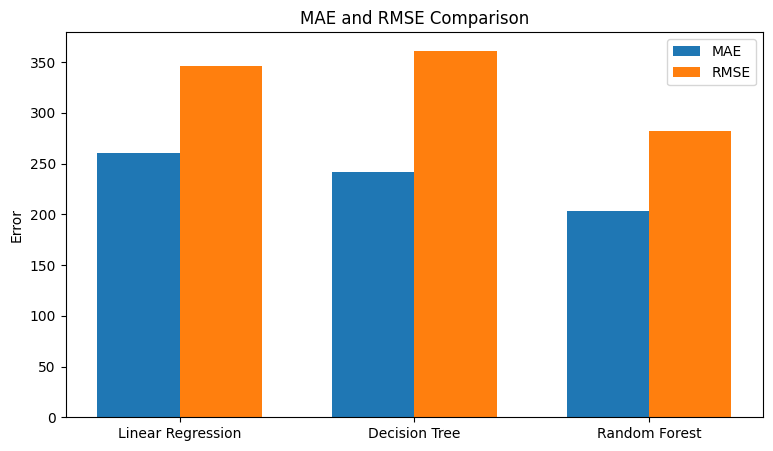

In [ ]:
mae_scores = [mae_lr, mae_dt, mae_rf]
rmse_scores = [rmse_lr, rmse_dt, rmse_rf]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, mae_scores, width, label="MAE")
plt.bar(x + width/2, rmse_scores, width, label="RMSE")

plt.xticks(x, models)
plt.ylabel("Error")
plt.title("MAE and RMSE Comparison")
plt.legend()

plt.show()

In [ ]:
from sklearn.svm import SVR

svm_model = SVR(kernel='rbf')

svm_model.fit(X_train_processed, y_train)

SVR()

In [ ]:
y_pred_svm = svm_model.predict(X_test_processed)


In [ ]:
mae_svm = mean_absolute_error(y_test, y_pred_svm)

rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))

r2_svm = r2_score(y_test, y_pred_svm)

print("SVM Results")
print("MAE :", mae_svm)
print("RMSE:", rmse_svm)
print("R2 Score:", r2_svm)

SVM Results
MAE : 501.4540634276027
RMSE: 721.9413826196137
R2 Score: -0.050086878939080925


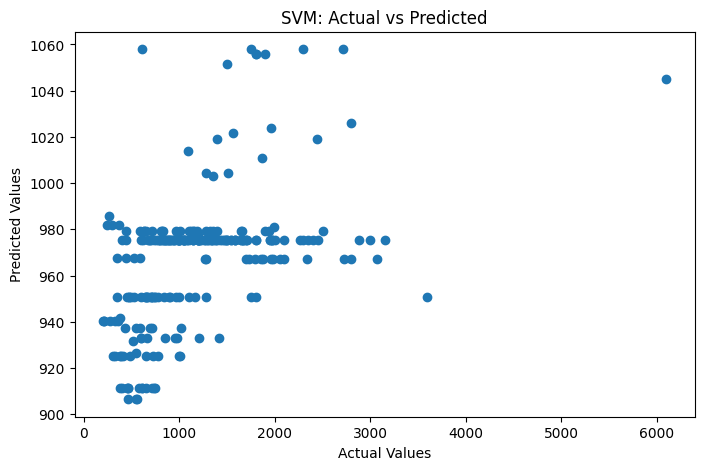

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_svm)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVM: Actual vs Predicted")

plt.show()

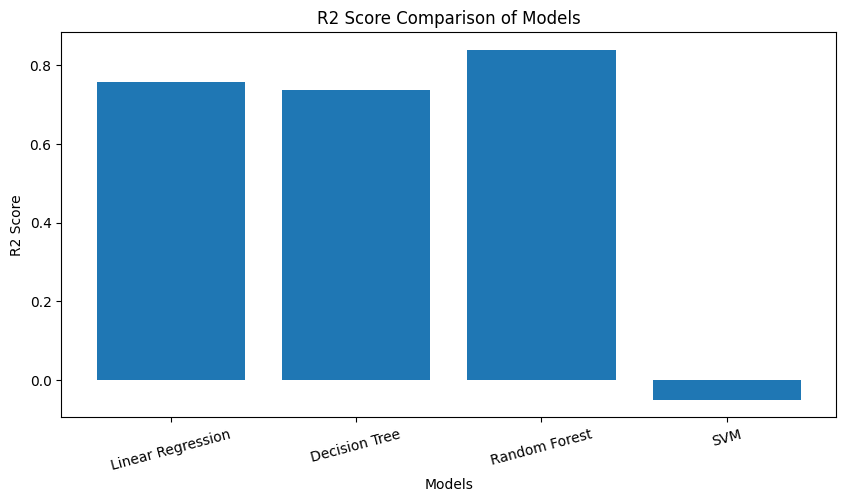

In [ ]:
models = ["Linear Regression", "Decision Tree", "Random Forest", "SVM"]

r2_scores = [r2_lr, r2_dt, r2_rf, r2_svm]

plt.figure(figsize=(10, 5))

plt.bar(models, r2_scores)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("R2 Score Comparison of Models")

plt.xticks(rotation=15)

plt.show()

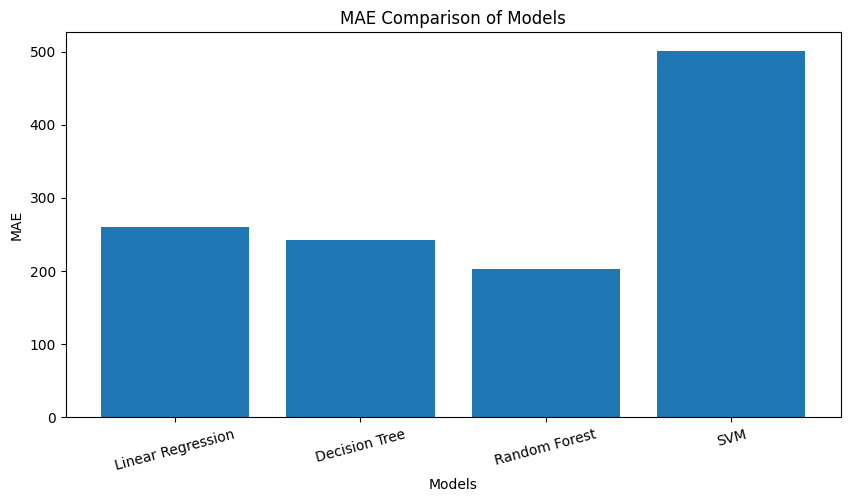

In [ ]:
mae_scores = [mae_lr, mae_dt, mae_rf, mae_svm]

plt.figure(figsize=(10, 5))

plt.bar(models, mae_scores)

plt.xlabel("Models")
plt.ylabel("MAE")
plt.title("MAE Comparison of Models")

plt.xticks(rotation=15)

plt.show()

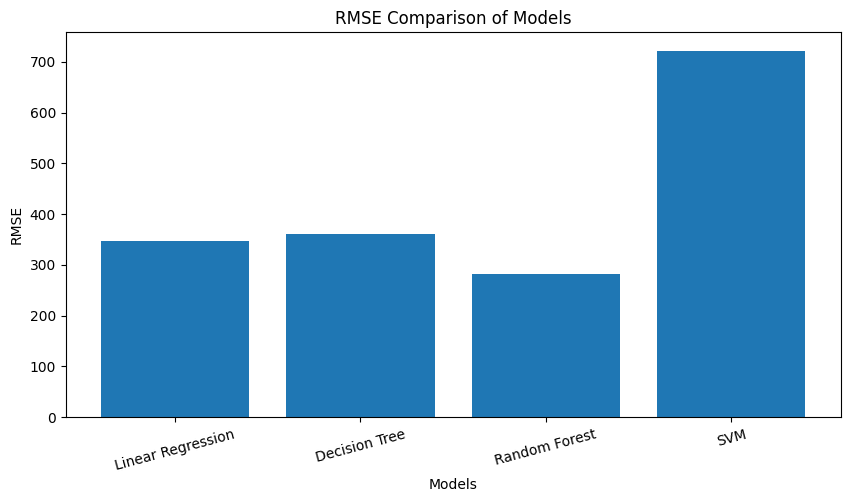

In [ ]:
rmse_scores = [rmse_lr, rmse_dt, rmse_rf, rmse_svm]

plt.figure(figsize=(10, 5))

plt.bar(models, rmse_scores)

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Models")

plt.xticks(rotation=15)

plt.show()

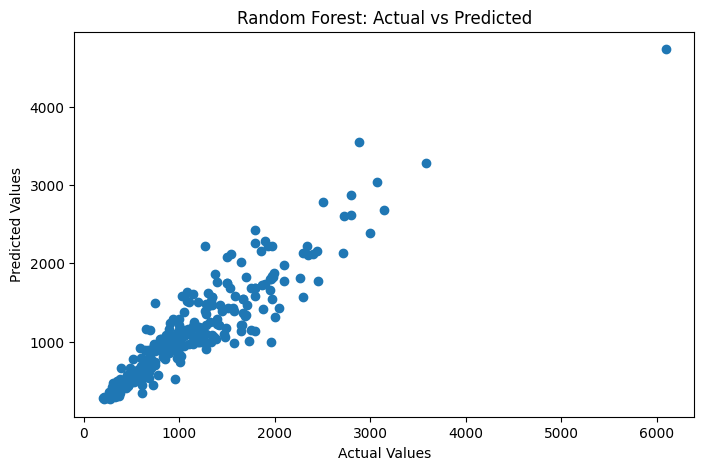

In [ ]:
best_predictions = y_pred_rf

plt.figure(figsize=(8, 5))

plt.scatter(y_test, best_predictions)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [ ]:
print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

print("\nDecision Tree")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

print("\nRandom Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

print("\nSVM")
print("MAE :", mae_svm)
print("RMSE:", rmse_svm)
print("R2 Score:", r2_svm)

Linear Regression
MAE : 260.6300940627527
RMSE: 346.1476341896686
R2 Score: 0.7585962047623799

Decision Tree
MAE : 241.96605448143902
RMSE: 361.2332933363389
R2 Score: 0.7370961782644859

Random Forest
MAE : 202.9360149071126
RMSE: 282.3043246997009
R2 Score: 0.8394329528305163

SVM
MAE : 501.4540634276027
RMSE: 721.9413826196137
R2 Score: -0.050086878939080925


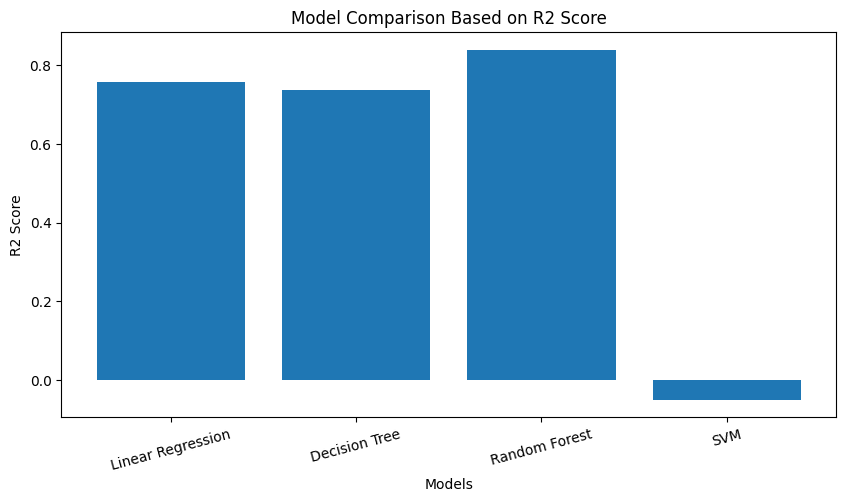

In [ ]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Decision Tree", "Random Forest", "SVM"]

r2_scores = [r2_lr, r2_dt, r2_rf, r2_svm]

plt.figure(figsize=(10, 5))

plt.bar(models, r2_scores)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison Based on R2 Score")

plt.xticks(rotation=15)

plt.show()

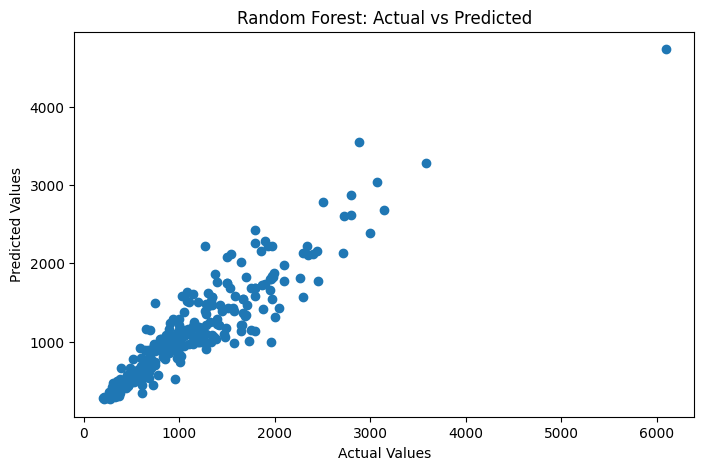

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

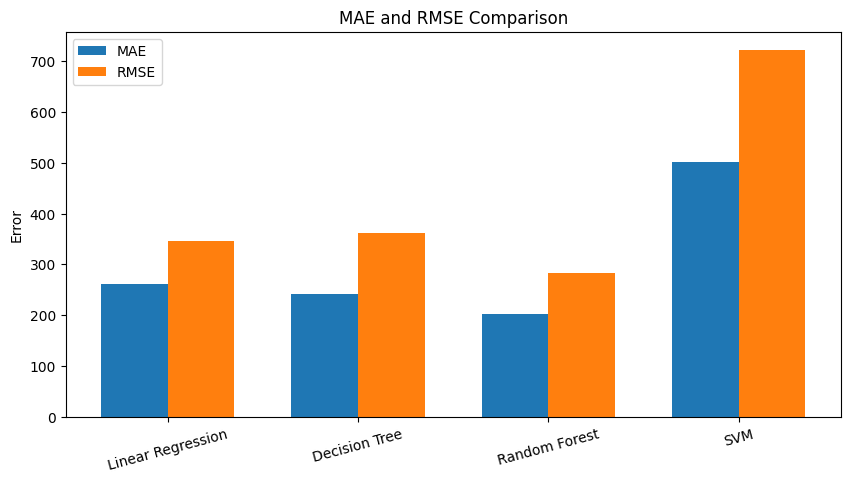

In [ ]:
import numpy as np

mae_scores = [mae_lr, mae_dt, mae_rf, mae_svm]
rmse_scores = [rmse_lr, rmse_dt, rmse_rf, rmse_svm]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(x - width/2, mae_scores, width, label="MAE")
plt.bar(x + width/2, rmse_scores, width, label="RMSE")

plt.xticks(x, models, rotation=15)
plt.ylabel("Error")
plt.title("MAE and RMSE Comparison")
plt.legend()

plt.show()